# Decision Trees

A decision tree is a supervised learning model used for classification and regression. It represents a hierarchical partitioning of the input space, where each internal node corresponds to a test on a feature, each branch corresponds to an outcome of the test, and each leaf node corresponds to a predicted target value or class.

## Formal Definition

Given a dataset $D = \{(x_i, y_i)\}_{i=1}^N$ with input vectors $x_i \in \mathbb{R}^d$ and target values $y_i$, a decision tree recursively partitions the feature space into regions $\{R_m\}_{m=1}^M$. The prediction function is

$f(x) = c_m \quad \text{for } x \in R_m,$

where $c_m$ is the label or predicted value assigned to region $R_m$.

## Tree Induction

The construction of a decision tree is typically greedy. At each node, the algorithm selects a feature $j$ and a threshold $t$ that minimize a chosen impurity measure after splitting the data into left and right subsets:

$D_{\text{left}} = \{(x_i, y_i) : x_{i,j} \le t\},$
$D_{\text{right}} = \{(x_i, y_i) : x_{i,j} > t\}.$

The split criterion maximizes the reduction in impurity, also called information gain.

## Impurity Measures

Common impurity measures include:

- Gini impurity for classification:

$I_{\text{Gini}}(D) = 1 - \sum_{k=1}^K p_k^2,$

where $p_k$ is the proportion of class $k$ in $D$.

- Entropy for classification:

$H(D) = -\sum_{k=1}^K p_k \log p_k.$

- Variance for regression:

$\text{Var}(D) = \frac{1}{|D|} \sum_{i=1}^{|D|} (y_i - \bar{y})^2,$

with $\bar{y} = \frac{1}{|D|}\sum_i y_i$.

The reduction in impurity for a split is

$\Delta I = I(D) - \frac{|D_{\text{left}}|}{|D|} I(D_{\text{left}}) - \frac{|D_{\text{right}}|}{|D|} I(D_{\text{right}}).$

## Prediction

For classification, the predicted class in region $R_m$ is usually the majority class:

$c_m = \arg\max_k \sum_{(x_i,y_i)\in D_m} \mathbf{1}\{y_i = k\}.$

For regression, the predicted value is typically the mean of targets in the region:

$c_m = \frac{1}{|D_m|} \sum_{(x_i,y_i)\in D_m} y_i.$

## Complexity

The time complexity of building a tree depends on the number of samples $N$, features $d$, and candidate splits. A typical greedy algorithm evaluates $O(dN \log N)$ operations when sorting is used for split selection. Prediction for a single sample requires $O(h)$ operations, where $h$ is the tree height.

## Pruning

A fully grown tree may overfit. Pruning reduces complexity by removing branches that contribute little to generalization. Two common strategies are:

- Pre-pruning: stop splitting when node size is below a threshold or when impurity reduction is insufficient.
- Post-pruning: grow a full tree, then remove subtrees based on a validation criterion, such as cost-complexity pruning.

In cost-complexity pruning, the objective is

$C_\alpha(T) = \sum_{m=1}^{|T|} N_m I(R_m) + \alpha |T|,$

where $N_m$ is the number of samples in leaf $m$, $I(R_m)$ is the impurity, $|T|$ is the number of leaves, and $\alpha$ is a complexity penalty.

## Properties

Advantages:
- Interpretability: the structure is easily understood.
- Nonlinear decision boundaries: can model complex relationships.
- No need for feature scaling.

Limitations:
- High variance: small data changes can alter the tree.
- Tendency to overfit without pruning.
- Bias toward features with many levels when using some split criteria.

Decision trees are the basis for ensemble methods such as random forests and gradient boosting, which mitigate variance and often improve predictive performance.

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Accuratezza sul test set: 0.98
Importanza delle feature:
 - sepal length (cm): 0.000
 - sepal width (cm): 0.000
 - petal length (cm): 0.551
 - petal width (cm): 0.449


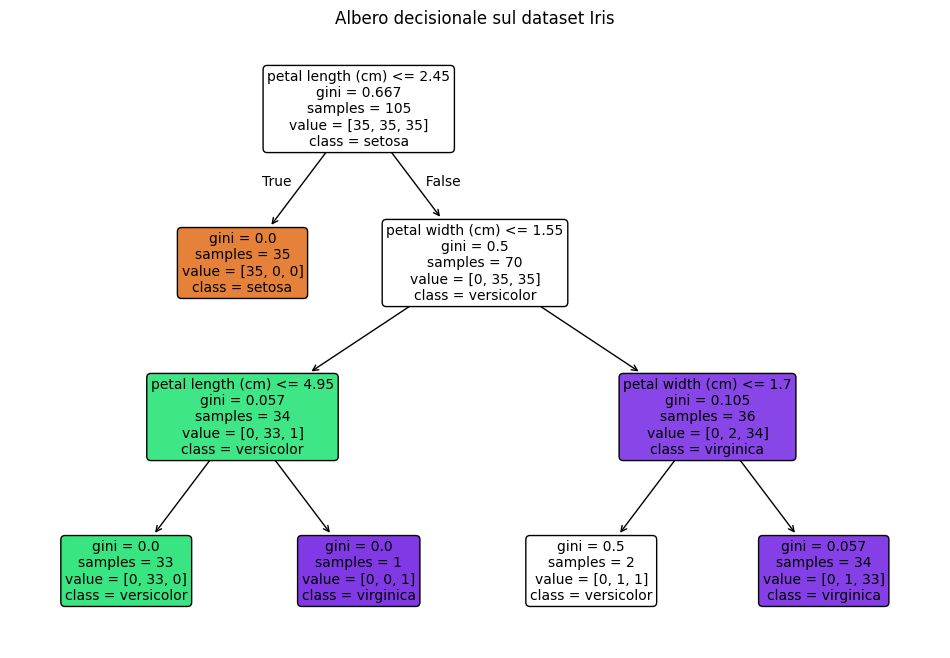

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd

import matplotlib.pyplot as plt

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
print(df.head())

X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42, stratify=iris.target
)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

print(f"Accuratezza sul test set: {clf.score(X_test, y_test):.2f}")
print("Importanza delle feature:")
for feature, importance in zip(iris.feature_names, clf.feature_importances_):
    print(f" - {feature}: {importance:.3f}")

plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Albero decisionale sul dataset Iris")
plt.show()